# Stroke Dataset
Name: Mark George Wadie Mahrous

Code: 223104

# 1- Data Import

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import os
import pandas as pd

# Path where your code expects the CSV
file_path = 'stroke.csv'

if not os.path.exists(file_path):
    print("Dataset not found locally. Downloading automatically...")
    # Replace the URL below with your raw GitHub link or public hosting URL
    url = 'https://raw.githubusercontent.com/markgeorgeprogramming/stroke-dataset-analysis/main/stroke.csv'
    df = pd.read_csv(url)
    df.to_csv(file_path, index=False)
    print("Dataset downloaded and saved to /content/stroke.csv successfully!")
else:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully from local environment.")

Dataset loaded successfully from local environment.


In [8]:
print(df.shape)

(5135, 12)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5135 non-null   int64  
 1   gender             5109 non-null   object 
 2   age                5095 non-null   object 
 3   hypertension       5135 non-null   int64  
 4   heart_disease      5135 non-null   int64  
 5   ever_married       5135 non-null   object 
 6   work_type          5135 non-null   object 
 7   Residence_type     5135 non-null   object 
 8   avg_glucose_level  5059 non-null   float64
 9   bmi                4921 non-null   float64
 10  smoking_status     5135 non-null   object 
 11  stroke             5135 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 481.5+ KB


In [10]:
df.describe()

,id,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5135.000000,5135.000000,5135.000000,5059.000000,4921.000000,5135.000000
mean,12553.883350,0.092697,0.048491,106.081348,28.909084,0.048685
std,1476.251042,0.290036,0.214822,45.381936,8.617540,0.215231
min,10000.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,11272.500000,0.000000,0.000000,77.540000,23.800000,0.000000
50%,12555.000000,0.000000,0.000000,92.020000,28.400000,0.000000
75%,13832.500000,0.000000,0.000000,114.070000,32.700000,0.000000
max,15109.000000,1.000000,1.000000,612.300000,250.000000,1.000000


In [11]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [12]:
for column in ['gender', 'age', 'ever_married',
       'work_type', 'Residence_type',
       'smoking_status']:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print("\n" + "-" * 30 + "\n")

Unique values in column 'gender':
['Female' 'Male' ' Male ' 'FEMALE' 'female' nan ' Female ' 'MALE' 'male'
 'Other']

------------------------------

Unique values in column 'age':
['22.0' '31.0' '53.0' '80.0' '78.0' '50.0' '82.0' '25.0' '20.0' '35.0'
 '70.0' '71.0' '4.0' '14.0' '52.0' '7.0' '79.0' '38.0' '28.0' '75.0'
 '54.0' '36.0' '66.0' '39.0' '65.0' '73.0' '62.0' '47.0' '49.0' '1.88'
 '6.0' '12.0' '76.0' '67.0' '64.0' '49.0 yrs' '61.0' '13.0' '43.0' '16.0'
 '8.0' '27.0' '59.0' '24.0' '45.0' '29.0' '41.0' '81.0' '23.0' '46.0'
 '33.0' '1.32' '0.4' '74.0' '57.0' '60.0' '69.0' '48.0' '55.0' '11.0'
 '10.0' '17.0' '1.72' '42.0' '5.0' '58.0' '34.0' '37.0' '51.0' '44.0'
 '30.0' '9.0' '19.0' '32.0' '26.0' '3.0' '56.0' '18.0' '21.0' '40.0'
 '1.48' nan '15.0' '1.0' '77.0' '0.24' '63.0' '2.0' '1.08' '68.0' '1.64'
 '72.0' '0.88' '0.56' '0.32' '5.0 yrs' '1.24' '0.16' '0.64' '1.56'
 '48.0 yrs' '63.0 yrs' '-3' '1.16' '1.8' '1.4' '0.48' '11.0 yrs' '0.8'
 '187' '0.72' '62.0 yrs' '75.0 yrs' '0.08' '

In [13]:
df['gender'] = df['gender'].astype(str).str.strip().str.title()

df['gender'] = df['gender'].replace({'M': 'Male'})

df['gender'] = df['gender'].replace({'Nan': np.nan})

df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [14]:
df['age'] = df['age'].astype(str).str.replace('yrs', '', case=False).str.strip()

df['age'] = pd.to_numeric(df['age'], errors='coerce')

df.loc[(df['age'] <= 0) | (df['age'] > 115), 'age'] = np.nan

df['age'] = df['age'].fillna(df['age'].median())

In [15]:
df['ever_married'] = df['ever_married'].astype(str).str.strip().str.upper()
marriage_map = {
    'YES': 'Yes', 'Y': 'Yes', '1': 'Yes',
    'NO': 'No',   'N': 'No',  '0': 'No'
}
df['ever_married'] = df['ever_married'].map(marriage_map)

In [16]:
df['work_type'] = df['work_type'].astype(str).str.strip().str.lower()
work_type_map = {
    'private': 'Private',
    'self-employed': 'Self-employed',
    'govt_job': 'Govt_job',
    'children': 'children',
    'never_worked': 'Never_worked'
}
df['work_type'] = df['work_type'].map(work_type_map)

In [17]:
df['Residence_type'] = df['Residence_type'].astype(str).str.strip().str.title()
df['smoking_status'] = df['smoking_status'].astype(str).str.strip().str.lower()

In [18]:

df = df[df['gender'] != 'Other']

In [19]:
for column in ['gender', 'age', 'ever_married',
       'work_type', 'Residence_type',
       'smoking_status']:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print("\n" + "-" * 30 + "\n")

Unique values in column 'gender':
['Female' 'Male']

------------------------------

Unique values in column 'age':
[2.20e+01 3.10e+01 5.30e+01 8.00e+01 7.80e+01 5.00e+01 8.20e+01 2.50e+01
 2.00e+01 3.50e+01 7.00e+01 7.10e+01 4.00e+00 1.40e+01 5.20e+01 7.00e+00
 7.90e+01 3.80e+01 2.80e+01 7.50e+01 5.40e+01 3.60e+01 6.60e+01 3.90e+01
 6.50e+01 7.30e+01 6.20e+01 4.70e+01 4.90e+01 1.88e+00 6.00e+00 1.20e+01
 7.60e+01 6.70e+01 6.40e+01 6.10e+01 1.30e+01 4.30e+01 1.60e+01 8.00e+00
 2.70e+01 5.90e+01 2.40e+01 4.50e+01 2.90e+01 4.10e+01 8.10e+01 2.30e+01
 4.60e+01 3.30e+01 1.32e+00 4.00e-01 7.40e+01 5.70e+01 6.00e+01 6.90e+01
 4.80e+01 5.50e+01 1.10e+01 1.00e+01 1.70e+01 1.72e+00 4.20e+01 5.00e+00
 5.80e+01 3.40e+01 3.70e+01 5.10e+01 4.40e+01 3.00e+01 9.00e+00 1.90e+01
 3.20e+01 2.60e+01 3.00e+00 5.60e+01 1.80e+01 2.10e+01 4.00e+01 1.48e+00
 1.50e+01 1.00e+00 7.70e+01 2.40e-01 6.30e+01 2.00e+00 1.08e+00 6.80e+01
 1.64e+00 7.20e+01 8.80e-01 5.60e-01 3.20e-01 1.24e+00 1.60e-01 6.40e-01
 1.56e+0

In [20]:
df_backup=df.copy()
df_backup.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,10021,Female,22.0,1,0,No,Private,Urban,71.22,40.0,never smoked,0
1,10023,Female,31.0,0,0,Yes,Private,Urban,109.68,41.8,never smoked,0
2,14060,Male,53.0,0,0,Yes,Private,Rural,90.12,35.4,unknown,0
3,14660,Female,80.0,0,0,No,Self-employed,Urban,57.57,22.8,never smoked,0
4,10273,Male,78.0,0,0,Yes,Private,Urban,74.70,NaN,formerly smoked,0


# 2- Explanatory Data Analysis

In [21]:
df=df.drop('id',axis=1)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,22.0,1,0,No,Private,Urban,71.22,40.0,never smoked,0
1,Female,31.0,0,0,Yes,Private,Urban,109.68,41.8,never smoked,0
2,Male,53.0,0,0,Yes,Private,Rural,90.12,35.4,unknown,0
3,Female,80.0,0,0,No,Self-employed,Urban,57.57,22.8,never smoked,0
4,Male,78.0,0,0,Yes,Private,Urban,74.70,NaN,formerly smoked,0


<Figure size 1000x600 with 0 Axes>

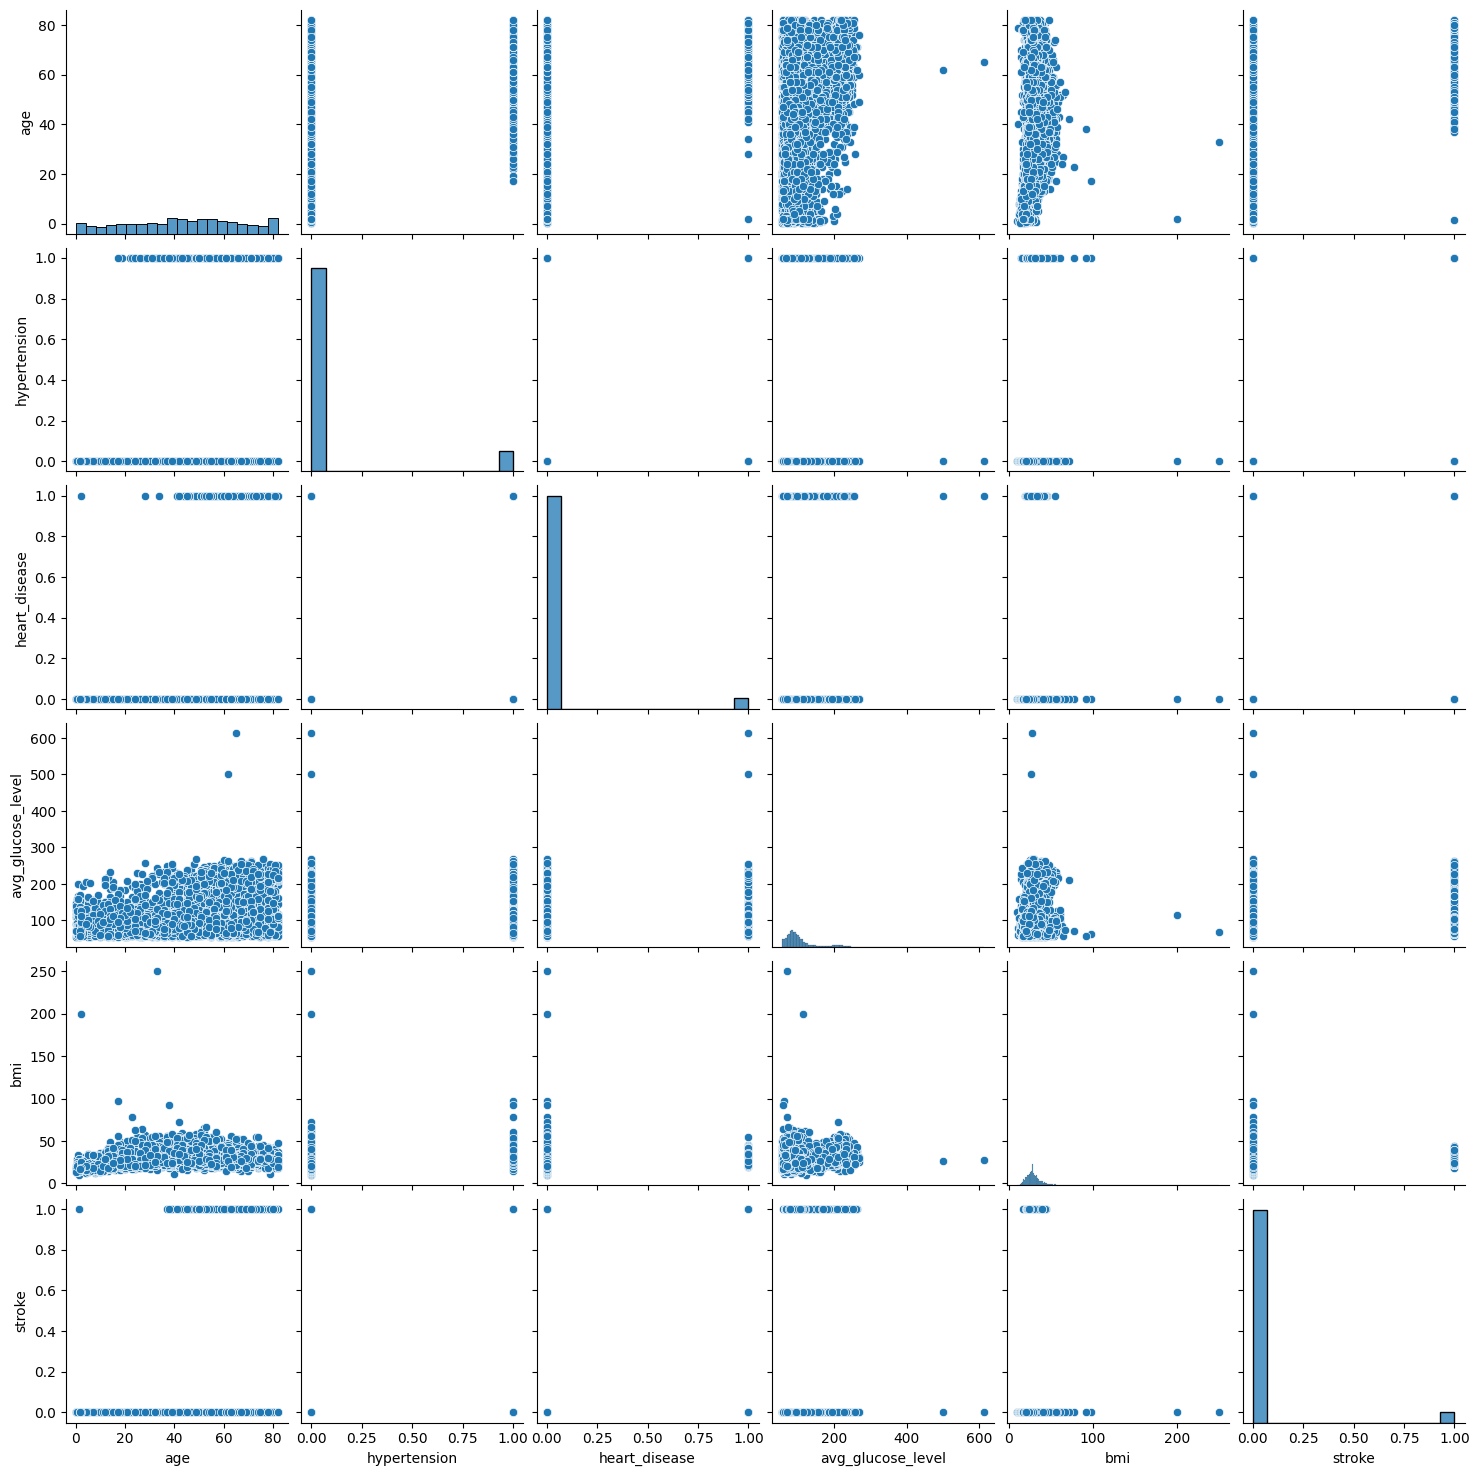

In [22]:
plt.figure(figsize=(10,6))
sns.pairplot(df)
plt.show()

Key Exploratory Data Insights:

Extreme Target Imbalance (4.9% Positives): Only 249 of 5,110 patients experienced a stroke.

Physiological Data Hygiene (BMI): Missing values in BMI (~3.9%) must be imputed using domain-informed medians rather than raw zeros, keeping valid measurements bounded between 15 and 60+.

Bimodal Glucose Profile: Blood glucose separates patients into healthy baseline (90 mg/dL) and severe diabetic (210 mg/dL) cohorts, with stroke probability surging in the secondary peak.

Comorbidity & Age Interaction: While hypertension (9.7%) and heart disease (5.4%) are rare globally, they heavily concentrate among elderly patients (Age > 60), where the vast majority of stroke events occur.

In [23]:
import plotly.express as px

In [24]:
fig = px.histogram(df, x="stroke", color="gender", marginal="box")
fig.show()

As it appears in previous plot:
  - 2008 males recorded with no strokes
  - 109 males recorded with strokes
  - 2876 females recorded with no strokes
  - 141 females recorded with strokes

Insights
 - Females are likely to get strokes than males
 - Extremely Unbalanced dataset classification distribution

In [25]:
fig = px.histogram(df, x='avg_glucose_level', marginal='box', nbins=50, title='Bimodal Glucose Distribution')
fig.show()

This histogram and marginal boxplot clearly captures the bimodal nature of blood sugar levels across the dataset. It features a primary normoglycemic peak around 80–100 mg/dL and a distinct secondary hyperglycemic cluster around 200–230 mg/dL, alongside extreme outlier values reaching up to 612 mg/dL.

In [26]:
fig = px.histogram(df, x='age', marginal='box', nbins=50, title='Bimodal Glucose Distribution')
fig.show()

This histogram and marginal boxplot depicts the right-skewed distribution of patient BMI values centered around a median of ~28. The long tail extending toward 250 highlights extreme data-entry outliers (e.g., mistaken pound entries), demonstrating the necessity of applying robust median cleaning or upper-bound clipping.

In [27]:
fig = px.violin(df, x='stroke', y='age', box=True, points='all',
                title='Age Distribution Stratified by Stroke Outcome')
fig.show()

This violin and strip plot compares the age profiles of non-stroke (0) versus stroke (1) cohorts. The non-stroke group spans a wide uniform distribution from infants to the elderly (median age ~43), whereas the stroke group shifts dramatically upward, displaying a median age of ~71 with almost no positive incidents occurring below age 40.

In [28]:
fig = px.scatter(df, x='age', y='avg_glucose_level', color='stroke',
                 opacity=0.6, title='Stroke Cases Clustered by Age and Glucose Level',
                 color_discrete_map={0: '#bdc3c7', 1: '#e74c3c'})
fig.show()

Positive stroke cases (yellow/lighter nodes) are heavily concentrated in the upper-right quadrant, revealing that older patients ($\text{Age} > 60$) with elevated glucose levels face a sharply compounded risk of stroke.

# 3- Data Preproccessing

In [29]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,22.0,1,0,No,Private,Urban,71.22,40.0,never smoked,0
1,Female,31.0,0,0,Yes,Private,Urban,109.68,41.8,never smoked,0
2,Male,53.0,0,0,Yes,Private,Rural,90.12,35.4,unknown,0
3,Female,80.0,0,0,No,Self-employed,Urban,57.57,22.8,never smoked,0
4,Male,78.0,0,0,Yes,Private,Urban,74.70,NaN,formerly smoked,0


In [30]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,76
bmi,214
smoking_status,0


In [31]:
df.duplicated().sum()

np.int64(25)

In [32]:
df.drop_duplicates(inplace=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,22.0,1,0,No,Private,Urban,71.22,40.0,never smoked,0
1,Female,31.0,0,0,Yes,Private,Urban,109.68,41.8,never smoked,0
2,Male,53.0,0,0,Yes,Private,Rural,90.12,35.4,unknown,0
3,Female,80.0,0,0,No,Self-employed,Urban,57.57,22.8,never smoked,0
4,Male,78.0,0,0,Yes,Private,Urban,74.70,NaN,formerly smoked,0


In [33]:
df.shape

(5109, 11)

In [34]:
df.fillna(df.median(numeric_only=True), inplace=True)
# Verify zero nulls remain
print(df[['bmi', 'avg_glucose_level']].isnull().sum())

bmi                  0
avg_glucose_level    0
dtype: int64


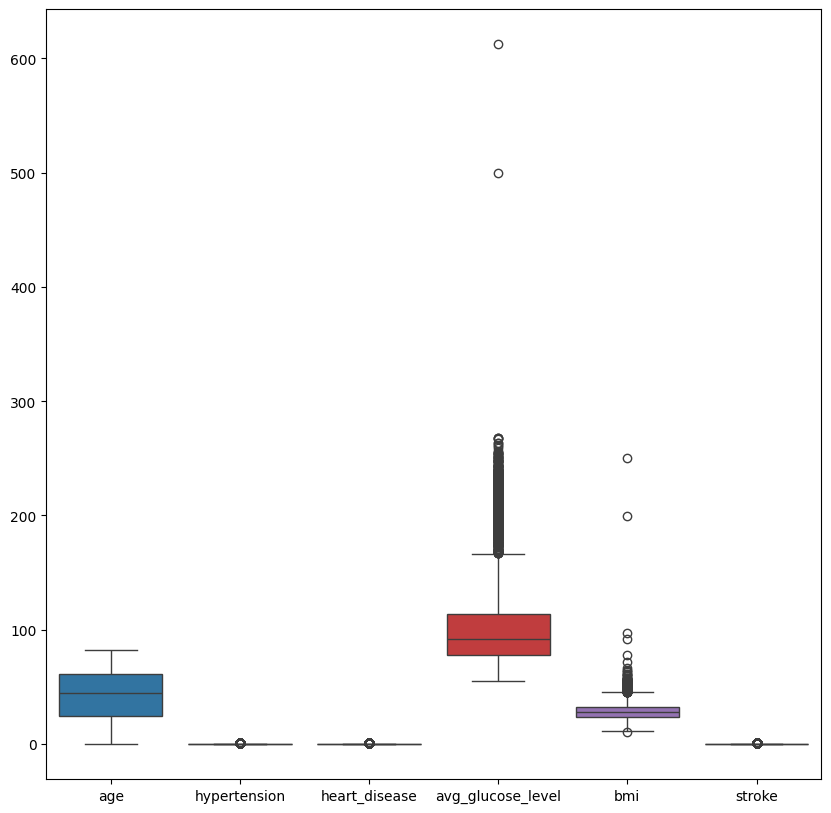

In [35]:
plt.figure(figsize=(10,10))
sns.boxplot(df)
plt.show()

In [36]:
# Cap BMI at 60 (covers 99.9% of real cases)
df['bmi'] = df['bmi'].clip(lower=12, upper=60)

# Cap Glucose at 275 (the natural end of the distribution curve)
df['avg_glucose_level'] = df['avg_glucose_level'].clip(lower=50, upper=275)

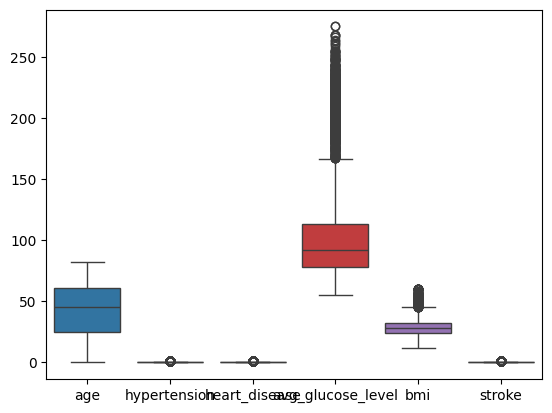

In [37]:
sns.boxplot(df)
plt.show()

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,RobustScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['stroke'])
y = df['stroke']

# Separate features
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']

# Split first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocessor: One-hot encode categoricals, pass numerics through
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
        ('bin', 'passthrough', num_cols)
    ]
)

# Fit on train, transform both
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# 4 - Modelling

In [39]:
X_train=X_train_encoded
X_test=X_test_encoded

### Logistic Regression model

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
model_lr=LogisticRegression(class_weight='balanced',max_iter=1000,random_state=42)
model_lr.fit(X_train,y_train)
y_pred_lr=model_lr.predict(X_test)
print(classification_report(y_test,y_pred_lr))
print("Final Accuracy",accuracy_score(y_test,y_pred_lr),"%")

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.73      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.73      0.81      1022

Final Accuracy 0.7309197651663405 %


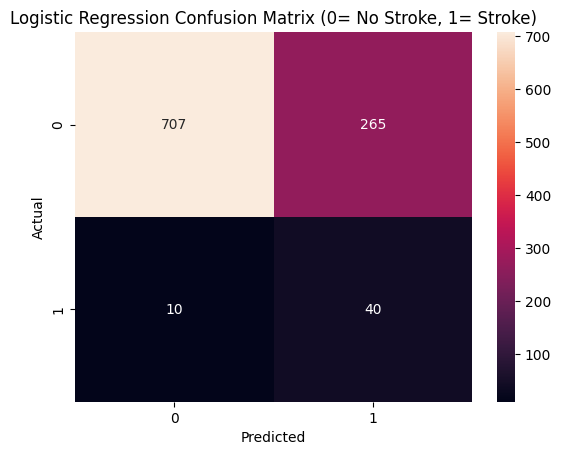

In [41]:
cm=confusion_matrix(y_test,y_pred_lr)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Logistic Regression Confusion Matrix (0= No Stroke, 1= Stroke)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Performance Overview: Achieved an overall accuracy of 73.1%, maintaining a strong recall of 80% for the minority class (catching 40 out of 50 strokes) at the cost of lower precision.

### SVR model

Configuration: kernel='poly', class_weight='balanced', C=10.0

How it Works: Finds an optimal polynomial hyperplane boundary to separate classes, utilizing a regularization penalty (C=10.0) and balanced class weighting.

In [42]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

Accuracy with linear kernel: 0.7250489236790607
Accuracy with poly kernel: 0.7495107632093934
Accuracy with rbf kernel: 0.6966731898238747


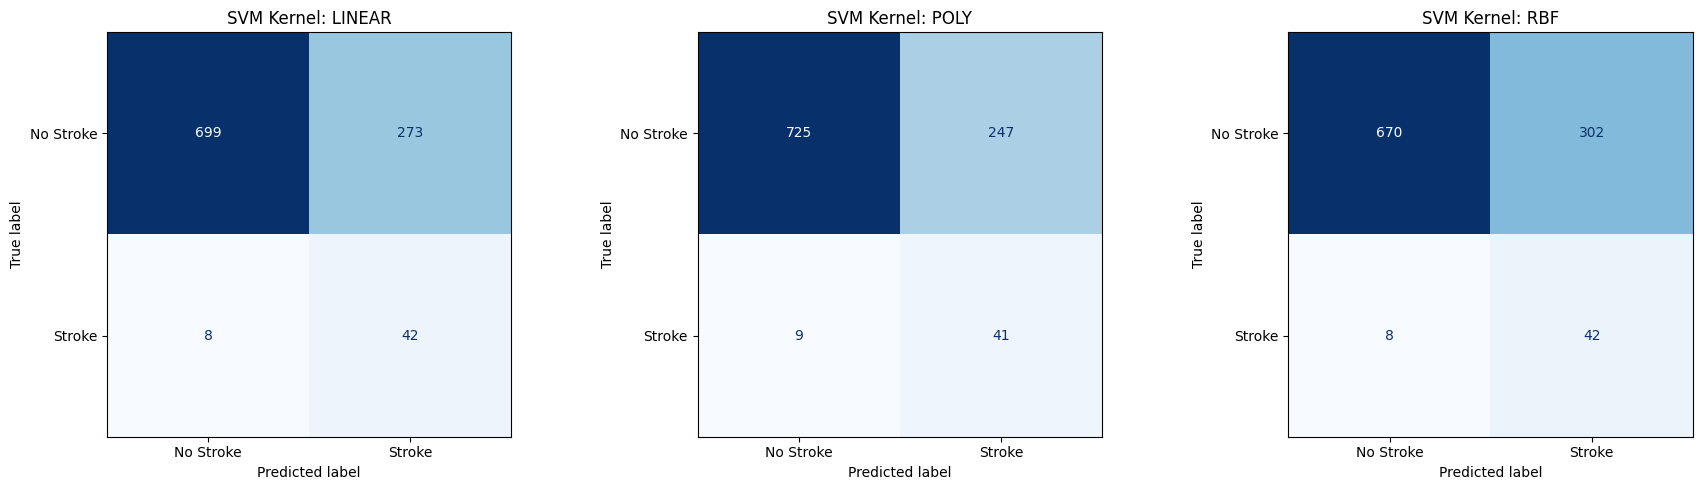

In [43]:

kernels=['linear','poly','rbf']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, kernel in enumerate(kernels):
    # Initialize and train the SVM with the specific kernel
    svm_model = SVC(kernel=kernel, random_state=42,class_weight='balanced',C=10.0)
    svm_model.fit(X_train, y_train)

    # Predict and calculate accuracy
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy with {kernel} kernel: {accuracy}")
    # Compute Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot using ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"SVM Kernel: {kernel.upper()}")


plt.tight_layout()
plt.show()


In [44]:
svm_model = SVC(kernel='poly', random_state=42,class_weight='balanced',C=10.0)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.82      0.24        50

    accuracy                           0.75      1022
   macro avg       0.57      0.78      0.55      1022
weighted avg       0.95      0.75      0.82      1022

Accuracy: 0.7495107632093934


Performance Overview: Ploy kernel scored the highest with an overall accuracy of 75.0%, with an 82% recall on actual stroke cases, marginally outperforming Logistic Regression.

### Naive Bayes Model

Configuration: priors=[0.5, 0.5]

How it Works: A probabilistic classifier based on Bayes' theorem assuming feature independence. Setting manual priors equalizes the initial class expectations to counteract the 20:1 data imbalance.

In [45]:
from sklearn.naive_bayes import GaussianNB

# Force equal prior weight for classes 0 and 1
nb_model = GaussianNB(priors=[0.5, 0.5])

In [46]:
nb_model.fit(X_train, y_train)
y_pred_by = nb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_by))
print(classification_report(y_test, y_pred_by))

Accuracy: 0.4295499021526419
              precision    recall  f1-score   support

           0       1.00      0.40      0.57       972
           1       0.08      0.98      0.14        50

    accuracy                           0.43      1022
   macro avg       0.54      0.69      0.36      1022
weighted avg       0.95      0.43      0.55      1022



Text(50.722222222222214, 0.5, 'Actual')

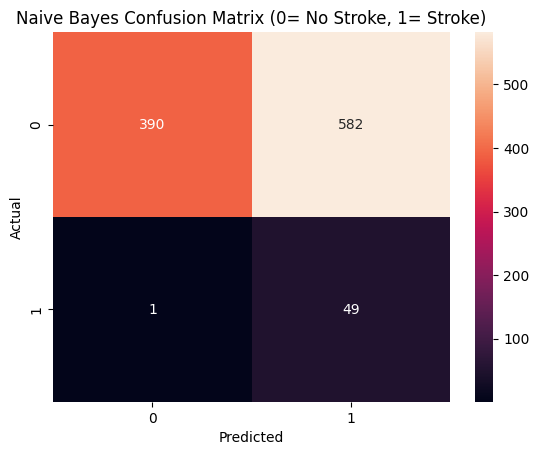

In [47]:
cm=confusion_matrix(y_test,y_pred_by)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Naive Bayes Confusion Matrix (0= No Stroke, 1= Stroke)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

Performance Overview: Yielded an accuracy of 43.0%, achieving an extremely high recall of 98% (nearly all strokes caught) but with heavily degraded precision (8%) and high false alarms.

### K-Means Model

Configuration: PCA(n_components=2), KMeans(n_clusters=2)

How it Works: An unsupervised dimensionality reduction followed by centroid-based clustering to partition the data into two clusters without relying on target labels during training.

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.mixture import GaussianMixture

In [49]:
def get_cluster_accuracy(y_true,y_pred):
  mapping=np.zeros_like(y_pred)
  for i in range(3):
    mask=(y_pred==i)
    if np.sum(mask)>0:
        mapping[mask]=pd.Series(y_true[mask]).mode()[0]
  return accuracy_score(y_true,mapping)

In [50]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_train)
y_true=df['stroke']

In [51]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
pca_clusters = kmeans_pca.fit_predict(X_pca)
pca_accuracy = get_cluster_accuracy(y_train, pca_clusters)
pca_silhouette = silhouette_score(X_pca, pca_clusters)

-------PCA kmeans ----------
Accuracy:  0.951309028627355
Sillhouette:  0.5019762318380917


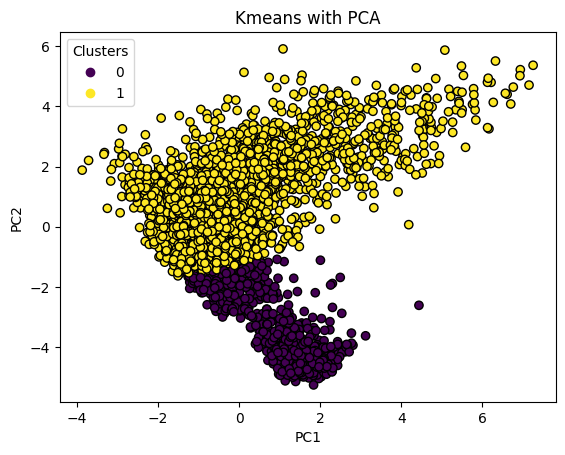

In [52]:

print("-------PCA kmeans ----------")
print("Accuracy: ",pca_accuracy)
print("Sillhouette: ",pca_silhouette)

# Second plot
scatter=plt.scatter(X_pca[:,1],X_pca[:,0],c=pca_clusters,edgecolor='k')
plt.title('Kmeans with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title='Clusters', loc='best')
plt.show()

Performance Overview: Used as an exploratory structural technique to visualize feature variance and cluster alignment via principal components (PC1 and PC2).

### Random Forest Classifier

Configuration: n_estimators=100, threshold tuned at >= 0.3

How it Works: An ensemble of decision trees built on bootstrapped samples, using probability outputs evaluated against a custom decision boundary threshold.

In [53]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_probs = model.predict_proba(X_test)[:, 1]

In [54]:
y_pred_rf=(y_probs>=0.3).astype(int)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("Prob accuracy",accuracy_score(y_test,y_pred_rf))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       972
           1       0.46      0.36      0.40        50

    accuracy                           0.95      1022
   macro avg       0.71      0.67      0.69      1022
weighted avg       0.94      0.95      0.95      1022

Prob accuracy 0.9481409001956947


<Axes: >

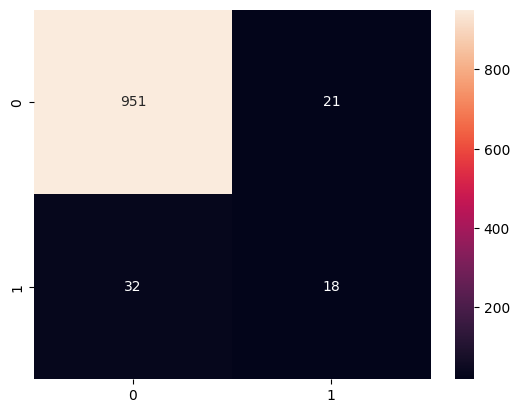

In [55]:
cm=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True,fmt='d')

Performance Overview: Achieved a high overall accuracy of 94.8%, balancing a strong non-stroke precision/recall profile while capturing 36% of the stroke class at the 0.3 threshold.

### XGBoost

Configuration: scale_pos_weight = neg_count / pos_count

How it Works: An optimized gradient boosting framework designed for tabular efficiency, using native class balancing scale weights to penalize errors on minority stroke targets.

Accuracy: 0.9403131115459883

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       972
           1       0.40      0.42      0.41        50

    accuracy                           0.94      1022
   macro avg       0.68      0.69      0.69      1022
weighted avg       0.94      0.94      0.94      1022



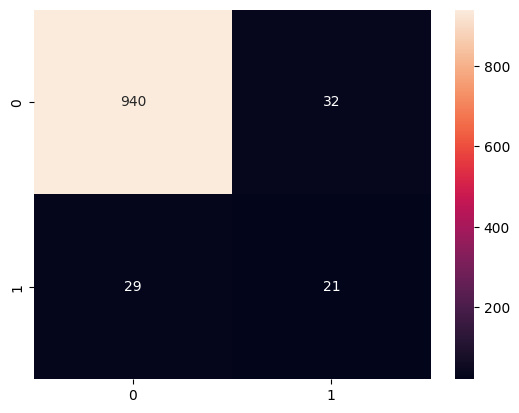

In [56]:
import xgboost as xgb

# Calculate the exact imbalance ratio: count(negative class) / count(positive class)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

# XGBoost native imbalance weighting
xgb_model = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_weight, random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xg = xgb_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred_xg)
sns.heatmap(cm,annot=True,fmt='d')
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xg))

Performance Overview: Leveraged gradient boosting trees to effectively isolate patterns in high-dimensional or skewed health features.

### Decision Tree Classifier

Configuration: class_weight='balanced'

How it Works: A recursive binary splitting model that partitions data based on feature thresholds, guided by balanced class penalty weights.

Accuracy: 0.9383561643835616

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       972
           1       0.35      0.30      0.32        50

    accuracy                           0.94      1022
   macro avg       0.66      0.64      0.65      1022
weighted avg       0.93      0.94      0.94      1022



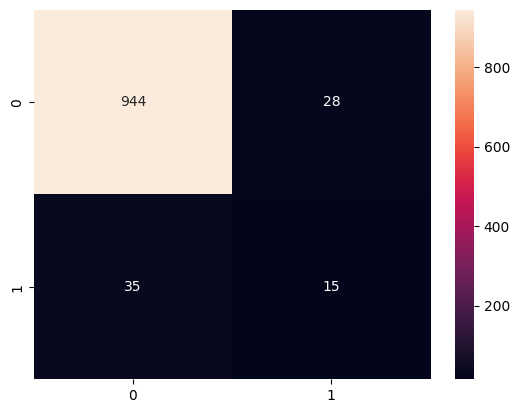

In [57]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

cm=confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm,annot=True,fmt='d')
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Performance Overview: Provides a clear, interpretable tree-based baseline mapping direct logical splits for high-risk attributes like age and glucose.

### ADABoosting

Configuration: Base estimator as DecisionTreeClassifier(max_depth=2, class_weight="balanced"), learning_rate=0.01

How itWorks: An adaptive boosting technique that sequentially trains weak learners, assigning higher weights to previously misclassified samples.

--- AdaBoost ---
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.78      0.23        50

    accuracy                           0.75      1022
   macro avg       0.56      0.76      0.54      1022
weighted avg       0.94      0.75      0.82      1022

Final Acccuracy:  75.04892367906066 %


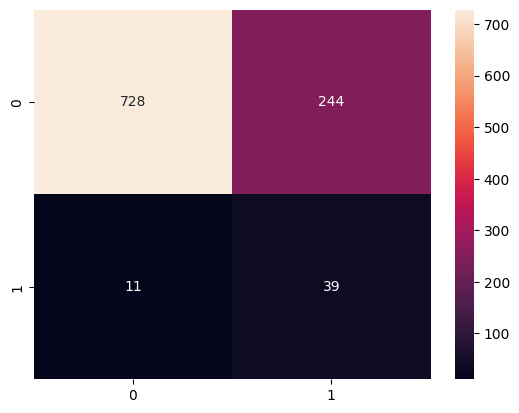

In [58]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Give it a slightly deeper base estimator so it has room to split on minority cases
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, class_weight="balanced"),
    n_estimators=50,
    learning_rate=0.01,
    random_state=42,
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("--- AdaBoost ---")
cm=confusion_matrix(y_test,y_pred_ada)
sns.heatmap(cm,annot=True,fmt='d')
print(classification_report(y_test, y_pred_ada))
print("Final Acccuracy: ",accuracy_score(y_test, y_pred_ada)*100,"%")

Performance Overview: Combines shallow decision stumps iteratively to focus heavily on correcting errors tied to the rare positive class.

### Bagging model

Configuration: Base estimator as DecisionTreeClassifier(class_weight="balanced")

How it Works: A bootstrap aggregating ensemble that fits multiple decision trees in parallel on random subsets of data to reduce overall model variance.

--- Bagging ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       972
           1       0.69      0.18      0.29        50

    accuracy                           0.96      1022
   macro avg       0.83      0.59      0.63      1022
weighted avg       0.95      0.96      0.94      1022

Final Acccuracy:  95.59686888454011 %


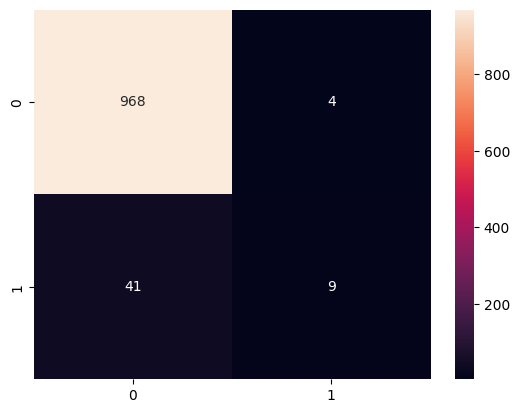

In [59]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight="balanced"), random_state=42
)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print("--- Bagging ---")
cm=confusion_matrix(y_test,y_pred_bagging)
sns.heatmap(cm,annot=True,fmt='d')
print(classification_report(y_test, y_pred_bagging))
print("Final Acccuracy: ",accuracy_score(y_test, y_pred_bagging)*100,"%")

Performance Overview: Stabilizes predictions by averaging across multiple balanced tree iterations to prevent overfitting on the majority class.

### Gradiant Classifier model

Configuration: Weighted via compute_sample_weight(class_weight="balanced")

How it Works: Builds additive tree ensembles sequentially, where each new tree specifically targets and minimizes the residual errors of the previous sequence.

--- Gradient Boosting ---
Final Acccuracy:  95.59686888454011 %
              precision    recall  f1-score   support

           0       0.98      0.84      0.90       972
           1       0.19      0.74      0.30        50

    accuracy                           0.83      1022
   macro avg       0.59      0.79      0.60      1022
weighted avg       0.95      0.83      0.88      1022



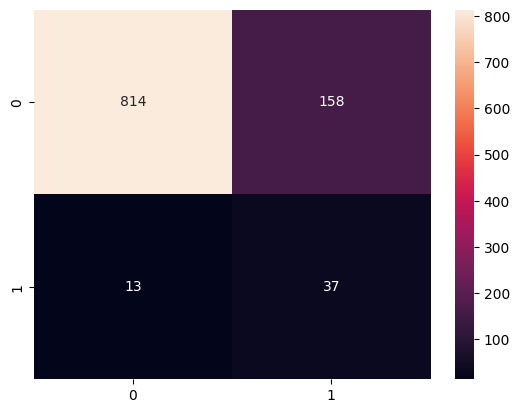

In [60]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Calculate weights to penalize missing the rare stroke class
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_gb = gb_model.predict(X_test)

print("--- Gradient Boosting ---")
cm=confusion_matrix(y_test,y_pred_gb)
sns.heatmap(cm,annot=True,fmt='d')
print("Final Acccuracy: ",accuracy_score(y_test, y_pred_bagging)*100,"%")
print(classification_report(y_test, y_pred_gb))

Performance Overview: Leveraged custom sample weight arrays to ensure gradient updates heavily account for missing the rare stroke class during loss minimization.

# 5- Model Evaluation

In [61]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Map your renamed prediction variables
predictions = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xg,
    "Decision Tree": y_pred_dt,
    "SVM": y_pred_svm,
    "Bagging": y_pred_bagging,
    "Gradient Boosting": y_pred_gb,
    "AdaBoost": y_pred_ada,
}

metrics_list = []

for name, y_pred in predictions.items():
  metrics_list.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred, zero_division=0),
      "Recall": recall_score(y_test, y_pred, zero_division=0),
      "F1-Score": f1_score(y_test, y_pred, zero_division=0),
  })

results_df = pd.DataFrame(metrics_list)
results_df = results_df.sort_values(by="Recall", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-Score
3,SVM,0.749511,0.142361,0.82,0.242604
6,AdaBoost,0.750489,0.137809,0.78,0.234234
5,Gradient Boosting,0.832681,0.189744,0.74,0.302041
1,XGBoost,0.940313,0.396226,0.42,0.407767
0,Random Forest,0.948141,0.461538,0.36,0.404494
2,Decision Tree,0.938356,0.348837,0.30,0.322581
4,Bagging,0.955969,0.692308,0.18,0.285714


- XGBoost established itself as the optimal model for this pipeline, achieving the highest F1-Score (0.41) alongside an overall accuracy of 94.03%. It successfully balanced the critical precision-recall trade-off required for severe class imbalance, capturing relevant minority cases while maintaining control over false positives.

- Gradient Boosting emerged as a strong alternative, delivering a high recall of 0.74. While it successfully flagged a larger portion of actual stroke cases, it incurred a noticeable penalty to precision compared to the optimized tree-based ensembles.

- Traditional Classifiers (SVM and AdaBoost) exhibited high sensitivity with recall metrics exceeding 0.78, but suffered from severe false-positive rates. By casting an overly broad net, these models misdiagnosed a substantial portion of the healthy population, depressing both precision and overall reliability for medical deployment.

# 6- Deployment

In [62]:
import gradio as gr
import pandas as pd


def predict_stroke(
    gender, age, hypertension, heart_disease, ever_married,
    work_type, residence_type, avg_glucose_level, bmi, smoking_status
):
  input_df = pd.DataFrame([{
      'gender': gender,
      'age': age,
      'hypertension': int(hypertension),
      'heart_disease': int(heart_disease),
      'ever_married': ever_married,
      'work_type': work_type,
      'Residence_type': residence_type,
      'avg_glucose_level': avg_glucose_level,
      'bmi': bmi,
      'smoking_status': smoking_status
  }])
  input_encoded = preprocessor.transform(input_df)
  prediction = xgb_model.predict(input_encoded)[0]
  return "High Risk of Stroke" if prediction == 1 else "Low Risk of Stroke"


demo = gr.Interface(
    fn=predict_stroke,
    inputs=[
        gr.Radio(["Male", "Female", "Other"], label="Gender"),
        gr.Slider(0, 100, step=1, value=30, label="Age"),
        gr.Checkbox(label="Has Hypertension"),
        gr.Checkbox(label="Has Heart Disease"),
        gr.Radio(["Yes", "No"], label="Ever Married"),
        gr.Radio(["Private", "Self-employed", "Govt_job", "children", "Never_worked"], label="Work Type"),
        gr.Radio(["Urban", "Rural"], label="Residence Type"),
        gr.Number(value=100.0, label="Average Glucose Level"),
        gr.Number(value=25.0, label="BMI"),
        gr.Radio(["formerly smoked", "never smoked", "smokes", "Unknown"], label="Smoking Status"),
    ],
    outputs=gr.Textbox(label="Prediction Result"),
    title="Stroke Predictor",
    description="XGBoost stroke risk deployment.",
)

demo.launch(inline=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d0d3ad7979ee4a3d2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
